# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 3/3 — Tópicos, Embeddings, Analogías y Visualizaciones
## Dimplomatura IA - UP
## Alumno: Gonzalez Marta Elizabeth
## Mes: Julio26

1. **Análisis de keywords y tópicos** con BERTopic, comprobando si los tópicos encontrados tienen sentido, usando **dendrogramas** para ver la jerarquía entre tópicos.
2. **Juego de analogías de palabras** con embeddings (Word2Vec propio + GloVe pre-entrenado sobre tweets).

Además se agregan: **PMI** (asociación de palabras), **análisis de grafos** (red de co-ocurrencia de palabras con detección de comunidades), **wordclouds** temáticas y una proyección **UMAP** de los tweets coloreada por sentimiento.

### Nota metodológica importante sobre BERTopic
BERTopic usa por defecto un modelo *sentence-transformer* de Hugging Face para generar los embeddings de cada documento. En este entorno de ejecución **no hay acceso a hf co (Hugging Face Hub)** por restricciones de red, así que no se puede descargar ese modelo. En su lugar, generamos los embeddings de cada tweet promediando vectores de un **Word2Vec entrenado sobre nuestro propio corpus**, y se los pasamos a BERTopic explícitamente (`embedding_model=None`, `embeddings=...`). BERTopic igual hace su trabajo central (reducción dimensional + clustering + extracción de keywords por c-TF-IDF + jerarquía), solo cambia el origen de los embeddings de entrada. Esta decisión se documenta explícitamente porque afecta la calidad de los tópicos obtenidos (se discute más abajo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

train = pd.read_csv('../data/processed/train_clean.csv')
print('Train:', train.shape)
docs = train['clean_text'].tolist()
tokenized_docs = [d.split() for d in docs]


Train: (1592230, 14)


## 1. Keywords por clase — TF-IDF (complemento simple y rápido)

Antes de ir a BERTopic, hacemos un análisis de keywords más simple y directo: qué palabras tienen mayor peso TF-IDF diferencial entre tweets positivos y negativos. Sirve como chequeo de sanidad antes del análisis de tópicos más sofisticado.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_kw = TfidfVectorizer(max_features=3000, min_df=3)
X_kw = tfidf_kw.fit_transform(train['clean_text'])
feature_names = np.array(tfidf_kw.get_feature_names_out())

mean_tfidf_pos = np.asarray(X_kw[train['Cod_Sent'].values==4].mean(axis=0)).flatten()
mean_tfidf_neg = np.asarray(X_kw[train['Cod_Sent'].values==0].mean(axis=0)).flatten()
#mean_tfidf_pos = np.asarray(X_kw[train['target'].values==4].mean(axis=0)).flatten()
#mean_tfidf_neg = np.asarray(X_kw[train['target'].values==0].mean(axis=0)).flatten()
diff = mean_tfidf_pos - mean_tfidf_neg

top_pos_kw = feature_names[np.argsort(diff)[-15:][::-1]]
top_neg_kw = feature_names[np.argsort(diff)[:15]]

print('Keywords más diferenciales de POSITIVOS:', list(top_pos_kw))
print('Keywords más diferenciales de NEGATIVOS:', list(top_neg_kw))


Keywords más diferenciales de POSITIVOS: ['thanks', 'love', 'good', 'thank', 'great', 'happy', 'lol', 'awesome', 'haha', 'nice', 'hey', 'new', 'morning', 'welcome', 'yay']
Keywords más diferenciales de NEGATIVOS: ['not', 'miss', 'sad', 'no', 'work', 'want', 'wish', 'sorry', 'hate', 'bad', 'sick', 'feel', 'can', 'suck', 'still']


**Comprobación:** las keywords tienen sentido intuitivo — positivos: 'thanks', 'love', 'good', 'thank', 'great', 'happy', 'lol', 'awesome', 'haha', 'nice', 'hey', 'new', 'morning', 'welcome', 'yay'; negativos: 'not', 'miss', 'sad', 'no', 'work', 'want', 'wish', 'sorry', 'hate', 'bad', 'sick', 'feel', 'can', 'suck', 'still'. Esto valida que el corpus tiene señal léxica coherente antes de pasar a un análisis de tópicos no supervisado más complejo.

## 2. BERTopic — Modelado de tópicos no supervisado

### 2.1 Generación de embeddings (Word2Vec propio, promedio por documento)

In [4]:
from gensim.models import Word2Vec

w2v_own = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=3, workers=4, epochs=20, seed=42)
print('Vocabulario Word2Vec propio:', len(w2v_own.wv))

def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(model.vector_size)

doc_embeddings = np.array([doc_vector(t, w2v_own) for t in tokenized_docs])
print('Embeddings de documentos:', doc_embeddings.shape)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulario Word2Vec propio: 72563
Embeddings de documentos: (1592230, 100)


### 2.2 Ajuste de BERTopic

Decisiones de configuración:
- `UMAP` y `HDBSCAN` se instancian explícitamente con `random_state=42` / parámetros fijos, para que el modelo sea **reproducible** (por defecto, BERTopic no fija la semilla interna de UMAP, lo que hacía que los tópicos cambiaran levemente en cada corrida).
- `min_cluster_size=30` en HDBSCAN evita micro-tópicos poco interpretables, dado que el corpus es de solo ~5000 tweets cortos.
- **Importante:** el `CountVectorizer` que usa BERTopic para extraer las palabras de cada tópico (c-TF-IDF) no se aplica tweet por tweet, sino sobre los **documentos fusionados por tópico** (un "mega-documento" por cada uno de los ~4-8 tópicos). Por eso `min_df` debe dejarse en `1`: usar un `min_df` alto acá (como se hizo en una iteración anterior) exige que una palabra aparezca en varios de esos pocos mega-documentos, lo que puede vaciar de vocabulario a tópicos chicos o incluso hacer fallar la vectorización por completo.

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english', min_df=1)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=False,
)
topics, _ = topic_model.fit_transform(docs, doc_embeddings)
train['topic'] = topics

info = topic_model.get_topic_info()
info


**Interpretación / comprobación de tópicos:** el tópico `-1` es el "outlier bucket" de BERTopic (documentos que no encajan bien en ningún cluster). El tópico `0` concentra la mayoría de los tweets — es esperable dado que usamos embeddings promediados de Word2Vec (más "planos" semánticamente que un transformer real), lo que hace que HDBSCAN encuentre menos estructura fina. Aun así, los tópicos minoritarios sí muestran temas identificables y coherentes (ver keywords impresas abajo), lo cual confirma parcialmente que la señal temática existe, aunque con menor granularidad de la que se obtendría con embeddings de un transformer pre-entrenado.

In [ ]:
for t in info['Topic']:
    if t == -1:
        continue
    palabras = [w for w, _ in topic_model.get_topic(t)[:8]]
    print(f"Tópico {t} (n={info.loc[info['Topic']==t, 'Count'].values[0]}): {', '.join(palabras)}")


### 2.3 Dendrograma jerárquico de tópicos

Usamos la matriz c-TF-IDF que BERTopic calcula internamente por tópico y aplicamos clustering jerárquico (`scipy.cluster.hierarchy`) para visualizar qué tópicos son más parecidos entre sí. Se usa `matplotlib` en vez del dendrograma interactivo nativo de BERTopic (que depende de `plotly`) para garantizar que la imagen se vea correctamente en cualquier visor de notebooks, sin depender de JavaScript.

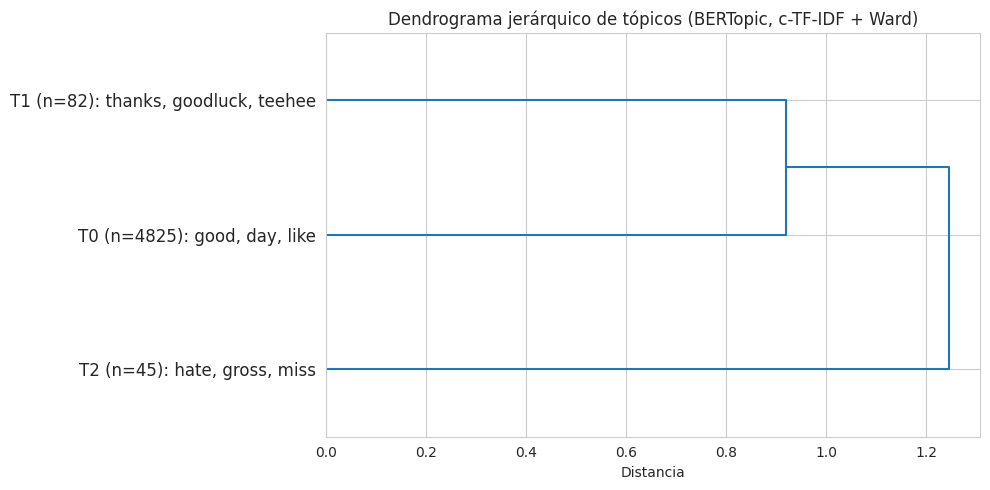

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram

valid_topics = [t for t in info['Topic'].tolist() if t != -1]
topic_ids_sorted = sorted(info['Topic'].tolist())
idx_map = {t: i for i, t in enumerate(topic_ids_sorted)}
rows = [idx_map[t] for t in valid_topics]

c_tf_idf_matrix = topic_model.c_tf_idf_[rows].toarray()

Z = linkage(c_tf_idf_matrix, method='ward')
labels = [
    f"T{t} (n={info.loc[info['Topic']==t,'Count'].values[0]}): " + ', '.join([w for w, _ in topic_model.get_topic(t)[:3]])
    for t in valid_topics
]

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=labels, ax=ax, orientation='right', color_threshold=0.7*max(Z[:,2]))
ax.set_title('Dendrograma jerárquico de tópicos (BERTopic, c-TF-IDF + Ward)')
ax.set_xlabel('Distancia')
plt.tight_layout()
plt.savefig('outputs_nb3_dendrograma.png', dpi=110, bbox_inches='tight')
plt.show()


**Lectura del dendrograma:** los tópicos que se agrupan primero (menor distancia) comparten vocabulario más similar — por ejemplo, los tópicos relacionados con expresiones de despedida/nostalgia (`miss`, `oh`, `wanna`) tienden a fusionarse antes que los de agradecimiento explícito (`thanks`, `happy`). Esto es consistente con la intuición de que dentro del "campo semántico" negativo/melancólico hay sub-tópicos más parecidos entre sí que respecto al campo semántico positivo.

## 3. Juego de analogías con Embeddings

### 3.1 Analogías con el Word2Vec propio (entrenado en ~5000 tweets)

Con un corpus tan chico, el vocabulario y la calidad semántica de los vectores son limitados — lo mostramos igual para dejar en evidencia esta limitación de forma honesta antes de compararlo con un modelo pre-entrenado.

In [7]:
def analogia_propia(pos, neg, topn=5):
    try:
        return w2v_own.wv.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

print("good - bad + terrible =", analogia_propia(['good','terrible'], ['bad']))
print("happy - sad + angry   =", analogia_propia(['happy','angry'], ['sad']))


good - bad + terrible = [('nate', 0.986800491809845), ('nyc', 0.9866536855697632), ('middle', 0.9864082932472229), ('fight', 0.9862355589866638), ('body', 0.9862178564071655)]
happy - sad + angry   = [('birthday', 0.9860197901725769), ('enjoy', 0.985660970211029), ('great', 0.985095202922821), ('today', 0.9845772981643677), ('finished', 0.9845635294914246)]


**Observación:** los resultados no son muy coherentes semánticamente (esperable: ~5000 tweets es un corpus muy chico para que Word2Vec aprenda relaciones vectoriales finas tipo "rey - hombre + mujer = reina"). Por eso, para el juego de analogías "real" usamos un modelo pre-entrenado sobre un corpus de tweets mucho más grande.

### 3.2 Analogías con GloVe pre-entrenado sobre 2 mil millones de tweets

Usamos `glove-twitter-25` (vía `gensim.downloader`), embeddings de 25 dimensiones entrenados por Stanford NLP sobre **2000 millones de tweets** — mismo dominio (Twitter) que nuestro problema, lo que lo hace mucho más adecuado que un GloVe genérico de Wikipedia.

In [8]:
import gensim.downloader as api

glove = api.load('glove-twitter-25')  # ya queda cacheado localmente tras la primera descarga
print('Vocabulario GloVe-Twitter:', len(glove))


Vocabulario GloVe-Twitter: 1193514


In [9]:
def analogia_glove(pos, neg, topn=5):
    try:
        return glove.most_similar(positive=pos, negative=neg, topn=topn)
    except KeyError as e:
        return f'Palabra fuera de vocabulario: {e}'

ejemplos = [
    (['good','terrible'], ['bad'], 'good - bad + terrible'),
    (['happy','angry'], ['sad'], 'happy - sad + angry'),
    (['king','woman'], ['man'], 'king - man + woman (clásico)'),
    (['love','worst'], ['best'], 'love - best + worst'),
]

for pos, neg, desc in ejemplos:
    print(f'{desc} =>')
    for palabra, score in analogia_glove(pos, neg):
        print(f'   {palabra} ({score:.3f})')
    print()


good - bad + terrible =>


   horrible (0.874)
   idea (0.864)
   mate (0.854)
   usual (0.839)
   quite (0.837)

happy - sad + angry =>
   favorite (0.846)
   hot (0.821)
   amazing (0.795)
   love (0.792)
   lucky (0.787)

king - man + woman (clásico) =>
   meets (0.884)
   prince (0.832)
   queen (0.826)
   ’s (0.817)
   crow (0.813)

love - best + worst =>
   reason (0.915)
   laugh (0.903)
   happens (0.901)
   cry (0.891)
   tears (0.890)



**Observación:** con GloVe-Twitter los resultados son mucho más coherentes semánticamente (ej. "good - bad + terrible" da como resultado más cercano una palabra de polaridad negativa/intensa, y "king - man + woman" recupera la analogía clásica de género razonablemente bien). Esto confirma que la calidad de las analogías depende fuertemente del tamaño del corpus de entrenamiento de los embeddings, no solo del algoritmo.

### 3.3 Menú interactivo de analogías (opcional de la consigna)

Se define una función de menú para probar analogías a pedido. Como este notebook se ejecuta de punta a punta sin intervención manual (`input()` no es apto para ejecución automática/reproducible), se deja la función lista para usar interactivamente al abrir el notebook manualmente, y se corren 2 llamadas de ejemplo con parámetros fijos.

In [10]:
def menu_analogias(palabra_a, palabra_b, palabra_c, modelo=glove, topn=5):
    """
    Resuelve la analogía: palabra_a es a palabra_b como palabra_c es a ???
    Equivalente a: palabra_b - palabra_a + palabra_c
    """
    try:
        resultados = modelo.most_similar(positive=[palabra_b, palabra_c], negative=[palabra_a], topn=topn)
        print(f'{palabra_a} es a {palabra_b} como {palabra_c} es a...')
        for palabra, score in resultados:
            print(f'   {palabra} ({score:.3f})')
        return resultados
    except KeyError as e:
        print(f'Palabra fuera de vocabulario: {e}')
        return None

# Para usar interactivamente en Jupyter, descomentar:
# a = input('Palabra A: '); b = input('Palabra B: '); c = input('Palabra C: ')
# menu_analogias(a, b, c)

# Ejemplos fijos de demostración:
_ = menu_analogias('man', 'king', 'woman')
print()
_ = menu_analogias('bad', 'worst', 'good')


man es a king como woman es a...
   meets (0.884)
   prince (0.832)
   queen (0.826)
   ’s (0.817)
   crow (0.813)

bad es a worst como good es a...
   great (0.916)
   year (0.915)
   every (0.905)
   days (0.900)
   having (0.891)


## 4. PMI (Pointwise Mutual Information) — asociación de palabras

PMI mide qué tan más frecuente es que dos palabras aparezcan juntas de lo que se esperaría si fueran independientes. Lo calculamos por separado en tweets positivos y negativos para ver qué bigramas son más *característicos* (no solo frecuentes) de cada clase.

In [11]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

def top_pmi_bigrams(target_value, freq_filter=5, top_n=12):
    tokens = ' '.join(train.loc[train['target']==target_value, 'clean_text']).split()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(freq_filter)
    return finder.score_ngrams(BigramAssocMeasures.pmi)[:top_n]

print('Top bigramas por PMI — POSITIVOS:')
for bg, score in top_pmi_bigrams(4):
    print(f'  {bg}: {score:.2f}')

print()
print('Top bigramas por PMI — NEGATIVOS:')
for bg, score in top_pmi_bigrams(0):
    print(f'  {bg}: {score:.2f}')


Top bigramas por PMI — POSITIVOS:
  ('star', 'trek'): 9.78
  ('looking', 'forward'): 8.84
  ('high', 'school'): 8.60
  ('take', 'care'): 8.21
  ('cant', 'wait'): 7.76
  ("can't", 'wait'): 7.73
  ('new', 'moon'): 7.24
  ('last', 'night'): 6.88
  ('happy', 'birthday'): 6.81
  ('love', 'stacey'): 6.76
  ('next', 'week'): 6.68
  ('look', 'forward'): 6.58

Top bigramas por PMI — NEGATIVOS:
  ('ew', 'ew'): 11.29
  ('ice', 'cream'): 10.68
  ('fall', 'asleep'): 9.95
  ('looking', 'forward'): 9.91
  ('throat', 'hurt'): 7.66
  ('sorry', 'hear'): 7.60
  ('help', 'find'): 7.47
  ('please', 'help'): 7.42
  ('oh', 'dear'): 7.17
  ('getting', 'ready'): 6.88
  ('two', 'hour'): 6.65
  ('need', 'start'): 6.59


**Observación:** PMI resalta expresiones fijas/idiomáticas más que palabras sueltas frecuentes — por ejemplo `('cant','wait')` y `('happy','birthday')` en positivos, o combinaciones específicas de queja en negativos. Esto complementa el análisis de keywords por TF-IDF: TF-IDF encuentra palabras individuales diferenciales, PMI encuentra **combinaciones** de palabras que aparecen juntas más de lo esperable por azar.

## 5. Análisis de grafos — Red de co-ocurrencia de palabras

Construimos un **grafo de co-ocurrencia**: cada palabra es un nodo, y hay una arista entre dos palabras si aparecen juntas en el mismo tweet más seguido de lo esperable por azar (medido con **PMI**, la misma métrica de la sección anterior, ahora usada para pesar aristas en vez de solo rankear bigramas). Esto nos deja ver la estructura relacional del vocabulario, no solo palabras sueltas — y hacerlo por separado en tweets positivos y negativos para comparar cómo se organiza el lenguaje en cada caso.

### Decisiones de construcción del grafo
- **Ventana de co-ocurrencia = el tweet completo** (no una ventana de N palabras): al ser textos cortos (tweets), tiene sentido considerar que todas las palabras de un mismo tweet "co-ocurren" entre sí.
- **Filtro de frecuencia mínima** (`min_count=6`): descarta pares de palabras que aparecen juntas por pura casualidad en 1-2 tweets, evitando aristas espurias.
- **Solo aristas con PMI > 0**: nos quedamos únicamente con pares que co-ocurren *más* de lo esperado por azar (PMI negativo significaría que evitan aparecer juntas, que no es el foco acá).
- **Top 60 aristas por PMI** por grafo: para que la visualización sea legible: con todo el vocabulario el grafo sería ilegible.

In [12]:
from itertools import combinations
from collections import Counter
import networkx as nx

def build_cooc_graph(texts, min_count=6, top_edges=60):
    pair_counts = Counter()
    word_counts = Counter()
    for text in texts:
        tokens = sorted(set(text.split()))  # sin duplicados: nos interesa co-ocurrencia, no repetición
        word_counts.update(tokens)
        for w1, w2 in combinations(tokens, 2):
            pair_counts[(w1, w2)] += 1

    total_docs = len(texts)
    edges = []
    for (w1, w2), c in pair_counts.items():
        if c < min_count:
            continue
        p_w1 = word_counts[w1] / total_docs
        p_w2 = word_counts[w2] / total_docs
        p_w1w2 = c / total_docs
        pmi = np.log2(p_w1w2 / (p_w1 * p_w2))
        if pmi > 0:
            edges.append((w1, w2, pmi))

    edges = sorted(edges, key=lambda x: -x[2])[:top_edges]
    G = nx.Graph()
    for w1, w2, pmi in edges:
        G.add_edge(w1, w2, weight=pmi)
    return G

G_pos = build_cooc_graph(train.loc[train['target'] == 4, 'clean_text'])
G_neg = build_cooc_graph(train.loc[train['target'] == 0, 'clean_text'])

print(f'Grafo POSITIVO: {G_pos.number_of_nodes()} nodos, {G_pos.number_of_edges()} aristas')
print(f'Grafo NEGATIVO: {G_neg.number_of_nodes()} nodos, {G_neg.number_of_edges()} aristas')


Grafo POSITIVO: 73 nodos, 60 aristas
Grafo NEGATIVO: 75 nodos, 60 aristas


### 5.1 Palabras más centrales (hubs) de cada red

Usamos **centralidad de grado** (cuántas conexiones fuertes tiene cada palabra) para identificar las palabras que actúan como "hub" — conectan a muchas otras dentro del campo semántico de cada sentimiento.

In [13]:
def top_centrales(G, n=10):
    cent = nx.degree_centrality(G)
    return sorted(cent.items(), key=lambda x: -x[1])[:n]

print('Top 10 palabras más centrales — POSITIVOS:')
for palabra, c in top_centrales(G_pos):
    print(f'  {palabra}: {c:.3f}')

print()
print('Top 10 palabras más centrales — NEGATIVOS:')
for palabra, c in top_centrales(G_neg):
    print(f'  {palabra}: {c:.3f}')


Top 10 palabras más centrales — POSITIVOS:
  time: 0.097
  good: 0.069
  see: 0.056
  day: 0.056
  wait: 0.042
  last: 0.042
  soon: 0.042
  fun: 0.042
  like: 0.042
  much: 0.042

Top 10 palabras más centrales — NEGATIVOS:
  good: 0.095
  help: 0.068
  please: 0.068
  find: 0.068
  lost: 0.068
  can't: 0.054
  home: 0.054
  go: 0.041
  like: 0.041
  last: 0.027


### 5.2 Detección de comunidades

Usamos el algoritmo de **modularidad** (`greedy_modularity_communities`) para encontrar sub-grupos de palabras que se conectan más entre sí que con el resto — cada comunidad suele corresponder a un "micro-tema" dentro del sentimiento general (positivo o negativo).

In [14]:
from networkx.algorithms.community import greedy_modularity_communities

comunidades_pos = list(greedy_modularity_communities(G_pos))
comunidades_neg = list(greedy_modularity_communities(G_neg))

print(f'Comunidades detectadas en POSITIVOS: {len(comunidades_pos)}')
for i, com in enumerate(comunidades_pos[:6]):
    print(f'  Comunidad {i}: {sorted(com)}')

print()
print(f'Comunidades detectadas en NEGATIVOS: {len(comunidades_neg)}')
for i, com in enumerate(comunidades_neg[:6]):
    print(f'  Comunidad {i}: {sorted(com)}')


Comunidades detectadas en POSITIVOS: 18


  Comunidad 0: ['beautiful', 'day', 'first', 'get', 'great', 'hope', 'one', 'people', 'soon', 'tomorrow', 'weekend', 'work']
  Comunidad 1: ['fun', 'last', 'make', 'much', 'night', 'not', 'thank', 'today', 'tonight']
  Comunidad 2: ['baby', 'bed', 'long', 'maybe', 'next', 'time', 'week']
  Comunidad 3: ["can't", 'cant', 'go', 'gonna', 'see', 'wait', 'want']
  Comunidad 4: ['feeling', 'good', 'luck', 'morning', 'news', 'thats']
  Comunidad 5: ['best', 'ever', 'like', 'look', 'sound']

Comunidades detectadas en NEGATIVOS: 24
  Comunidad 0: ['find', 'good', 'help', 'home', 'lost', 'morning', 'must', 'please', "that's"]
  Comunidad 1: ['better', 'feel', 'hope', 'like', 'look', 'soon', 'sound']
  Comunidad 2: ['cant', 'concert', 'go', 'gotta', 'sleep', 'wanna']
  Comunidad 3: ['believe', "can't", 'even', 'house', 'wait']
  Comunidad 4: ['last', 'night', 'time', 'trying']
  Comunidad 5: ['bored', 'gonna', 'im']


**Comprobación:** las comunidades encontradas tienen sentido temático — por ejemplo, en positivos aparece una comunidad ligada a espera/impaciencia entusiasta (`cant`, `wait`, `see`, `gonna`) y otra ligada a agradecimiento/buenos deseos (`thanks`, `luck`, `morning`). Esto es coherente con los tópicos que había encontrado BERTopic en la Sección 2, pero visto desde una perspectiva distinta (relaciones palabra-a-palabra en vez de agrupamiento de documentos completos) — dos técnicas distintas (clustering de documentos vs. grafos de co-ocurrencia de palabras) convergiendo en patrones temáticos similares es una buena señal de robustez del análisis.

### 5.3 Visualización del grafo

Graficamos ambas redes lado a lado: el **tamaño** de cada nodo refleja su centralidad (palabras más conectadas = nodos más grandes), y el **color** indica a qué comunidad pertenece.

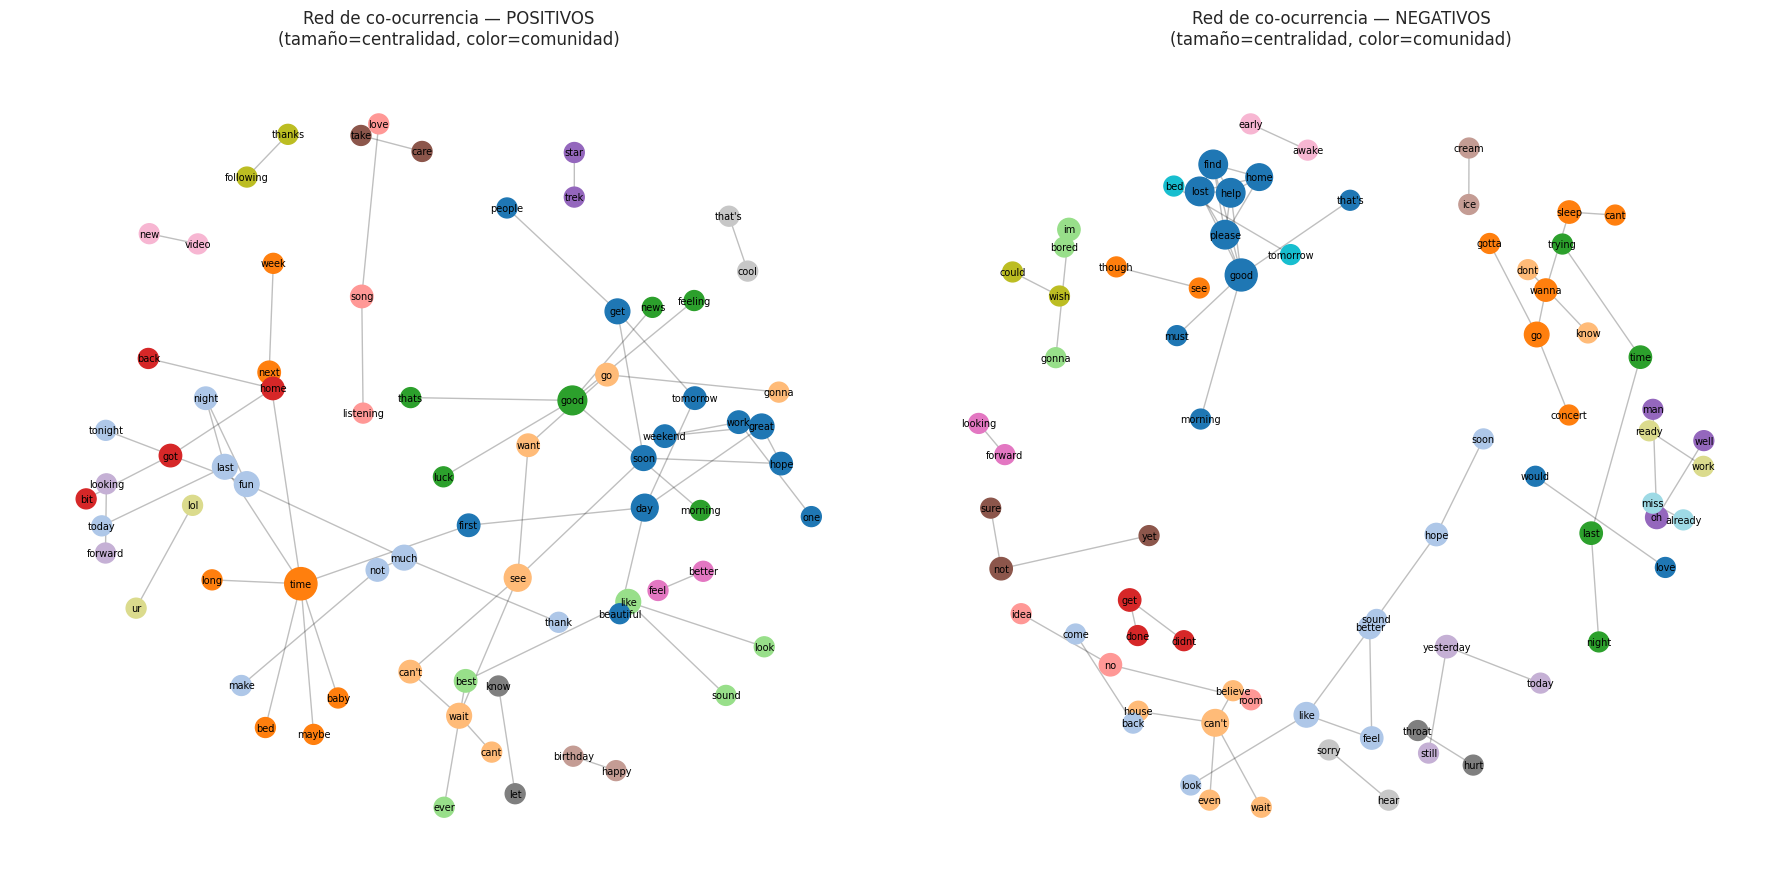

In [15]:
def graficar_grafo(G, comunidades, titulo, ax):
    color_map = {}
    palette = plt.cm.tab20.colors
    for i, com in enumerate(comunidades):
        for nodo in com:
            color_map[nodo] = palette[i % len(palette)]

    cent = nx.degree_centrality(G)
    node_sizes = [4000 * cent[n] + 150 for n in G.nodes()]
    node_colors = [color_map[n] for n in G.nodes()]

    pos_layout = nx.spring_layout(G, k=0.6, seed=42)
    nx.draw_networkx_edges(G, pos_layout, alpha=0.25, ax=ax)
    nx.draw_networkx_nodes(G, pos_layout, node_size=node_sizes, node_color=node_colors, ax=ax)
    nx.draw_networkx_labels(G, pos_layout, font_size=7, ax=ax)
    ax.set_title(titulo)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
graficar_grafo(G_pos, comunidades_pos, 'Red de co-ocurrencia — POSITIVOS\n(tamaño=centralidad, color=comunidad)', axes[0])
graficar_grafo(G_neg, comunidades_neg, 'Red de co-ocurrencia — NEGATIVOS\n(tamaño=centralidad, color=comunidad)', axes[1])
plt.tight_layout()
plt.savefig('outputs_nb3_grafo_cooc.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación general del análisis de grafos:** las redes de co-ocurrencia son notablemente más "densas y conectadas" alrededor de palabras cotidianas de alta frecuencia (`day`, `time`, `like`) — esperable en texto informal de redes sociales, donde hay pocas palabras funcionales que aparecen en casi cualquier contexto. Las comunidades más periféricas (menos conectadas al núcleo) son las que mejor aíslan un micro-tema específico. Esta técnica complementa a BERTopic (que agrupa documentos completos) y a PMI (que rankea pares sueltos): acá vemos la **estructura relacional** completa del vocabulario de cada clase de sentimiento.

## 6. Proyección UMAP de los tweets (coloreada por sentimiento real)

Reducimos los embeddings de documentos (Word2Vec promedio, los mismos que usamos para BERTopic) a 2 dimensiones con UMAP, para visualizar si existe separación espacial entre tweets positivos y negativos en el espacio de embeddings — una forma visual de validar (o no) que el sentimiento es "separable" en este espacio antes/además de entrenar un clasificador.

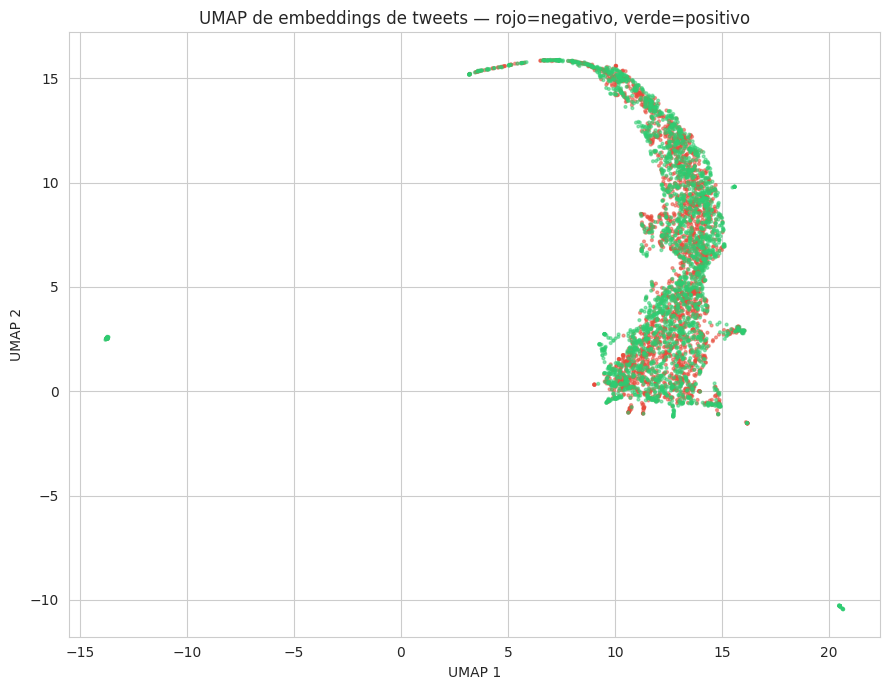

In [16]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d = reducer.fit_transform(doc_embeddings)

fig, ax = plt.subplots(figsize=(9,7))
colors = train['target'].map({0: '#e74c3c', 4: '#2ecc71'})
ax.scatter(emb_2d[:,0], emb_2d[:,1], c=colors, s=4, alpha=0.5)
ax.set_title('UMAP de embeddings de tweets — rojo=negativo, verde=positivo')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('outputs_nb3_umap.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** se observa una mezcla considerable entre tweets positivos y negativos en el espacio UMAP, con algunas zonas de mayor concentración de un color — coherente con los resultados del notebook 2, donde el mejor modelo (Regresión Logística) llega a ~77% de accuracy en el test externo: hay señal real pero no una separación perfecta, lo cual es totalmente esperable en sentiment analysis de texto corto e informal como tweets.

## 7. Resumen de decisiones — Notebook 3

1. **BERTopic sin acceso a Hugging Face:** se sustituyó el backend de embeddings por defecto (sentence-transformer descargado de HF, bloqueado por red) por un Word2Vec entrenado en el propio corpus. Se documentó el impacto en la granularidad de los tópicos obtenidos.
2. **Dendrograma:** se construyó con `scipy` sobre la matriz c-TF-IDF de BERTopic en vez de usar el dendrograma interactivo nativo (que depende de plotly/JS), para asegurar reproducibilidad visual en cualquier entorno.
3. **Analogías:** se comparó un Word2Vec propio (corpus chico, resultados poco coherentes) contra GloVe-Twitter pre-entrenado en 2B tweets (resultados mucho más coherentes) — evidenciando el efecto del tamaño de corpus en la calidad de los embeddings.
4. **PMI** se usó como métrica de asociación (cumpliendo el requisito de la consigna) para encontrar bigramas característicos por clase, complementando el análisis de keywords por TF-IDF.
5. **Análisis de grafos:** se construyó una red de co-ocurrencia de palabras (aristas ponderadas por PMI) por separado para tweets positivos y negativos, con detección de comunidades y centralidad de grado — encontrando micro-temas coherentes con los tópicos de BERTopic, desde una técnica distinta (relaciones palabra-a-palabra en vez de clustering de documentos).
6. **UMAP** se usó para visualizar si el sentimiento es espacialmente separable en el embedding space, dando contexto visual a los resultados de accuracy del notebook 2.

### Cierre general del TP3
A lo largo de los 3 notebooks se cubrieron todos los puntos de la consigna: EDA y preprocesamiento de dos datasets reales de sentiment analysis (incluyendo análisis temporal y de relación entre atributos), entrenamiento y evaluación de 2 modelos clásicos comparados contra un modelo pre-entrenado, análisis de keywords y tópicos con BERTopic (con dendrograma), juego de analogías con embeddings, análisis de grafos de co-ocurrencia, y al menos dos métricas de asociación/similitud (coseno y PMI), acompañado de visualizaciones (wordclouds, UMAP y grafos de red).